# Assignment 7
### Do any five.

##### I did problems 1, 2, 4, 7, and 12.

## 1. 

- What is the expected value of a single die roll?
$$
\mathbb{E}[X] = \frac{1}{6}1+\frac{1}{6}2+\frac{1}{6}3+\frac{1}{6}4+\frac{1}{6}5+\frac{1}{6}6 = \frac{21}{6} = 3.5
$$
- What is the expected value of rolling two dice and adding the results together?
$$
\mathbb{E}[X] =
\frac{1}{36}2 +
\frac{2}{36}3 +
\frac{3}{36}4 +
\frac{4}{36}5 +
\frac{5}{36}6 +
\frac{6}{36}7 +
\frac{5}{36}8 +
\frac{4}{36}9 +
\frac{3}{36}10 +
\frac{2}{36}11 +
\frac{1}{36}12 = \frac{252}{36} = 7
$$
- What is the expected winnings of any gamble in European roulette?
$$
-0.027027
$$

- Imagine you roll a die, and you record the value you get. But, if you roll a six, you roll again, and add that value. What is the expected value?
$$
4.0833
$$
- Imagine that the process described in the last question continues until you fail to roll a six. What is the expected value of the process? (This can be tricky, you can simulate it to get an answer if you prefer. Hint: The answer is 4.2.

In [1]:
import numpy as np
import pandas as pd

from assignment_6 import metabric_data


def roll_until_not_six():
    total = 0
    while True:
        roll = np.random.randint(1, 7)
        total += roll
        if roll != 6:
            break
    return total

trials = 100000
results = [roll_until_not_six() for _ in range(trials)]
expected_value = np.mean(results)
expected_value

np.float64(4.21661)

## 2. 
- Compute the expected value for a uniform random variable.
$$
\mathbb{E}[X] = \int_{a}^{b} x \frac{1}{b-a} dx = \frac{a+b}{2} = \frac{1}{2}
$$
- Show that $\mathbb{E}[a+bX] = a + b\mathbb{E}[X]$
$$
\mathbb{E}[a+bX] = \int_{-\infty}^{+\infty} (a + bx)f(x)dx = \int_{-\infty}^{+\infty} af(x) + bxf(x)dx = a \int_{-\infty}^{+\infty} f(x)dx + b \int_{-\infty}^{+\infty} xf(x)dx =a + b \mathbb{E}[X] \int_a^b f(x) dx = F(b) - F(a) F(-\infty)=0 and F(+\infty)=1
$$
- Show, by example, that $v(\mathbb{E}[X]) \neq \mathbb{E}[v(X)]$, if $v(x) \neq a+bx$. For example, try $v(y) = y^2$ or $v(y)=\sqrt{y}$ with a Bernoulli or uniform or normally distributed random variable. This can be an important thing to remember: The expectation of a transformed random variable is not the transformation of the expected value.

E[X]: 0.4916558869651117
v(E[X]): 0.2417255111874507
E[v(X)]: 0.3207092517528123


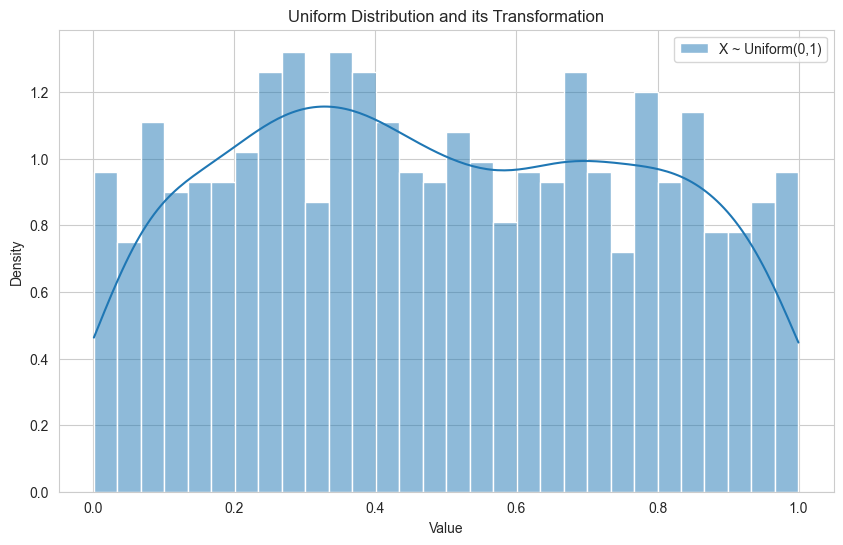

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

a, b = 0, 1

X = np.random.uniform(low=a, high=b, size=1000)

def v(y):
    return y**2

E_X = X.mean()
v_E_X = v(E_X)
E_v_X = np.mean(v(X))

print(f"E[X]: {E_X}")
print(f"v(E[X]): {v_E_X}")
print(f"E[v(X)]: {E_v_X}")

x = np.linspace(a, b, 100)
plt.figure(figsize=(10, 6))
sns.histplot(X, bins=30, kde=True, stat='density', label='X ~ Uniform(0,1)')
plt.title('Uniform Distribution and its Transformation')
plt.xlabel('Value')
plt.ylabel('Density')
plt.legend()
plt.show()

The results show that v(E[X]) and E[v(X)] are not equal, demonstrating that the expectation of a transformed random variable is not the transformation of the expected value.

## 3. 
- Compute the variance for a uniform random variable.
- Show that 
$$
\mathbb{V}[X] = \mathbb{E}[X^2] - \mathbb{E}[X]^2
$$
$$
\mathbb{V}[a+bX] = b^2 \mathbb{V}[X]
$$
- Show that if $X$ is a normally distributed random variable, then $a + bX$ is distributed normally with mean $a+ b \mathbb{E}[X]$ and variance $b^2 \sigma_X^2$ 

These properties get used all the time!


## 4.

- The **covariance** of $X$ and $Y$ is
$$
\text{cov}(X,Y) = \int_{y} \int_{x} (x-\mathbb{E}[X])(y-\mathbb{E}[Y])f_{XY}(x,y) dxdy = \mathbb{E}_{XY}[ (x-\mu_X)(y-\mu_Y)]
$$
- Show that if $f_{XY}(x,y)=f_X(x)f_Y(y)$, then $\text{cov}(X,Y)=0$
$$
\text{cov}(X,Y) = \int_{y} \int_{x} (x-\mathbb{E}[X])(y-\mathbb{E}[Y])f_X(x)f_Y(y) dxdy = \int_{x} (x-\mathbb{E}[X])f_X(x) dx \int_{y} (y-\mathbb{E}[Y])f_Y(y) dy = 0 \cdot 0 = 0
$$

- Provide an example (computation/simulation is fine) where $\text{cov}(X,Y)\approx 0$ but $f_{XY}(x,y)\neq 0$ The covariance doesn't characterize joint random variables except in a few special cases: The covariance only captures the **linear** association between the two variables, not nonlinear associations.

Covariance between X and Y: 0.0053738064888384845


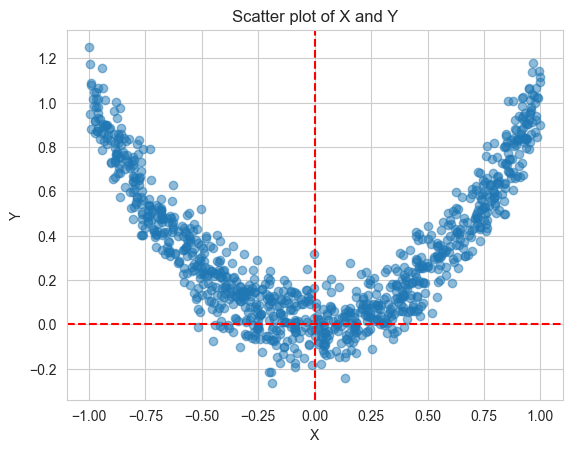

In [4]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)
n = 1000
X = np.random.uniform(-1, 1, n)
Y = X**2 + np.random.normal(0, 0.1, n)
cov_XY = np.cov(X, Y)[0, 1]
print(f"Covariance between X and Y: {cov_XY}")

plt.scatter(X, Y, alpha=0.5)
plt.title('Scatter plot of X and Y')
plt.xlabel('X')
plt.ylabel('Y')
plt.axhline(0, color='red', linestyle='--')
plt.axvline(0, color='red', linestyle='--')
plt.show()

This shows that even though the covariance between X and Y is close to zero, there is a clear nonlinear relationship between the two variables, demonstrating that covariance does not capture all types of associations.

## 5. 

Suppose $X$ has an expectation $\mathbb{E}[X]<\infty$ and variance $\mathbb{V}[X]<\infty$; this isn't always true, but is *usually* true
- Consider making a new variable, $\varepsilon = X - \mathbb{E}[X]$
- What's the expectation of $\varepsilon$?
- What's the variance of $\varepsilon$?
- So we can write any random variable in the form $X = \mathbb{E}[X] + \varepsilon, $ where $\mathbb{E}[\varepsilon]=0$ and $\mathbb{V}[\varepsilon] = \sigma_X^2$
- If that's true, show that we can also write any random variable in the form $X = \mathbb{E}[X] + \sigma_X \varepsilon$, where $\mathbb{E}[\varepsilon]=0$ and $\mathbb{V}[\varepsilon]=1$
- Now replace $\mathbb{E}[X]$ with $x\beta$, and the stage is set for regression models

## 6.
- Use the Taylor series expansions 
$$
F(x+h) = F(x) + hf(x) + \frac{h^2}{2}f'(x) + O(h^3)
$$ 
and 
$$
F(x-h) = F(x) - h f(x) + \frac{h^2}{2} f'(x)+ O(h^3)
$$
to show that
$$
\mathbb{E}[\hat{f}_{X,h}(x)] = \frac{F(x+h)-F(x-h)}{2h} = f(x) + O(h^2),
$$
so the **bias** of the KDE is $O(h^2)$, unlike the ECDF, for which $\mathbb{E}[\hat{F}(x)] = F(x)$.

## 7.
- Suppose $X$ and $Y$ are distributed bivariate normal. Show that if $\rho=0$, then $X$ and $Y$ are independent.
- For the multivariate normal, show that if $\Sigma$ is a diagonal matrix, then $X_1, X_2, ..., X_n$ are independent.
- For the multivariate normal, show that if $\Sigma$ is a diagonal matrix and all the $\sigma_i^2$ and all the $\mu_i$ are equal, then $X_1, X_2, ..., X_n$ are independently distributed random variables with distribution $N(\mu, \sigma^2)$

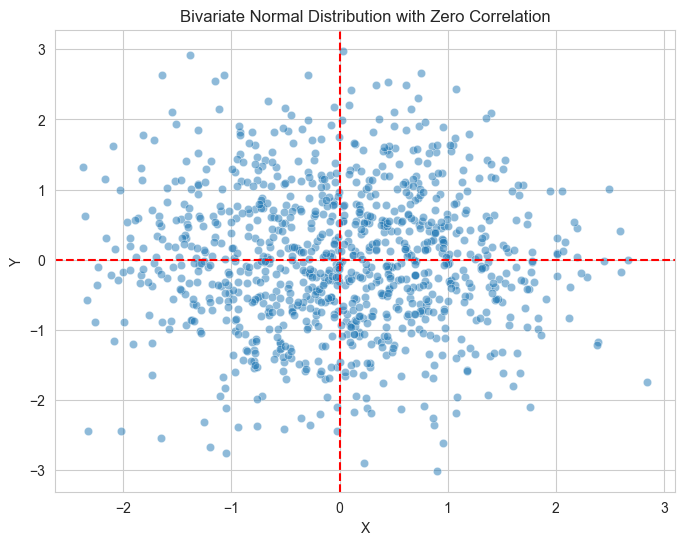

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

mean = [0, 0]
cov = [[1, 0], [0, 1]]  # Diagonal covariance matrix implies independence
data = np.random.multivariate_normal(mean, cov, size=1000)
x, y = data.T

plt.figure(figsize=(8, 6))
sns.scatterplot(x=x, y=y, alpha=0.5)
plt.title('Bivariate Normal Distribution with Zero Correlation')
plt.xlabel('X')
plt.ylabel('Y')
plt.axhline(0, color='red', linestyle='--')
plt.axvline(0, color='red', linestyle='--')
plt.show()
# The scatter plot shows no apparent relationship between X and Y, confirming their independence when ρ=0.

For the multivariate normal, show that if $\Sigma$ is a diagonal matrix, then $X_1, X_2, ..., X_n$ are independent.

In [7]:
import numpy as np
mean = [0, 0, 0]
cov = [[1, 0, 0], [0, 1, 0], [0, 0, 1]] # Diagonal covariance matrix
data = np.random.multivariate_normal(mean, cov, size=1000)
x1, x2, x3 = data.T

cov_matrix = np.cov(data, rowvar=False)
print("Covariance Matrix:\n", cov_matrix)
# The covariance matrix is diagonal, confirming that X1, X2, and X3 are independent.

Covariance Matrix:
 [[ 0.99751131  0.06200622 -0.01524427]
 [ 0.06200622  0.9321769   0.04986186]
 [-0.01524427  0.04986186  0.96092514]]


In [10]:
import numpy as np

mean = [5, 5, 5]
cov = [[2, 0, 0], [0, 2, 0], [0, 0, 2]] # Diagonal covariance matrix with equal variances

data = np.random.multivariate_normal(mean, cov, size=1000)
x1, x2, x3 = data.T

cov_matrix = np.cov(data, rowvar=False)
print("Covariance Matrix:\n", cov_matrix)

# The covariance matrix is diagonal with equal variances, confirming that X1, X2, and X3 are independently distributed as N(5, 2).

Covariance Matrix:
 [[ 1.99601246 -0.05648413 -0.02725197]
 [-0.05648413  1.97858815  0.140158  ]
 [-0.02725197  0.140158    1.91948118]]


## 8.
- Open the METABRIC data. Make a histogram of 'Ratio Therapy'.
- Let treatment, $T$ be distributed binomial with parameter $p$. Then the contribution to the likelihood for each patient $i$, with $y_i = 0$ for no radiation therapy and $y_i=1$ for radiation therapy, is 
$$
p^{y_i}(1-p)^{1-y_i}
$$
- Write out the likelihood.
- Maximize the likelihood with respect to $p$. What is the MLE, $\hat{p}$?
- Bootstrap the sampling density/distribution of $\hat{p}$.

## 9.
- Open the Ames house price data. Make a KDE of 'price'. Select an appropriate distribution for modeling it, and explain why you selected it. (Hint: You might want to take a common transformation of price.)
- Derive the density for this distribution.
- Write out the likelihood.
- Maximize the likelihood. What is the MLE?
- Plot the density/distribution for your fitted model and compare it to the KDE/ECDF. Criticize the fit.
- Bootstrap the sampling density/distribution of your parameters.

## 10.
- Open the METABRIC data. Make a KDE of 'Overall Survival (Months)'.
- Let survival time, $T$ be distributed exponentially with parameter $\lambda$. Then its distribution is
$$
F(t) = 1 - e^{-\lambda t} = p[T\le t].
$$
- Derive the density for this distribution.
- Write out the likelihood.
- Maximize the likelihood with respect to $\lambda$. What is the MLE, $\hat{\lambda}$?
- Plot the density/distribution for your fitted model and compare it to the KDE/ECDF. Criticize the fit.
- Bootstrap the sampling density/distribution of $\hat{\lambda}$.

## 11.
- Open the Ames house price data. Make a histogram of 'TotRms.AbvGrd', or total rooms above ground.
- We're going to model this using the Poisson Distribution. The probability that $y_i = k$ is given by
$$
pr[y_i = k ] = \frac{ \lambda^k e^{-\lambda} }{k!}
$$
- Write out the likelihood.
- Maximize the likelihood. What is the MLE? (Hint: The sample mean. As usual.)
- Plot the density/distribution for your fitted model and compare it to the KDE/ECDF. Criticize the fit.
- Bootstrap the sampling density/distribution of your parameter.

## 12.
- Open the METABRIC data. Make a histogram of 'Mutation Count' with around 50 bins. Let $Y$ be the mutation count the random variable, and $y_i$ the mutation count for patient $i$.
- We're going to model this using the Poisson Distribution. The probability that $y_i = k$ is given by
$$
pr[y_i = k ] = \frac{ \lambda^k e^{-\lambda} }{k!}
$$
- Write out the likelihood.
- Maximize the likelihood. What is the MLE? (Hint: The sample mean. As usual.)
- Plot the density/distribution for your fitted model and compare it to the KDE/ECDF. Criticize the fit.
- Bootstrap the sampling density/distribution of your parameter.

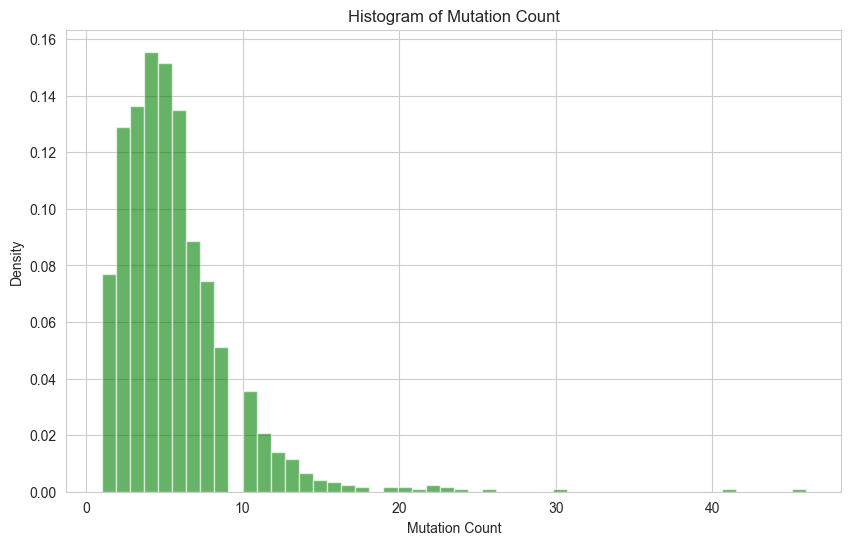

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

metabric_data = pd.read_csv("data/metabric.csv")

mutation_counts = metabric_data['Mutation Count'].dropna()

plt.figure(figsize=(10, 6))
plt.hist(mutation_counts, bins=50, density=True, alpha=0.6, color='g')
plt.title('Histogram of Mutation Count')
plt.xlabel('Mutation Count')
plt.ylabel('Density')
plt.show()

MLE for λ: 5.494415487714073


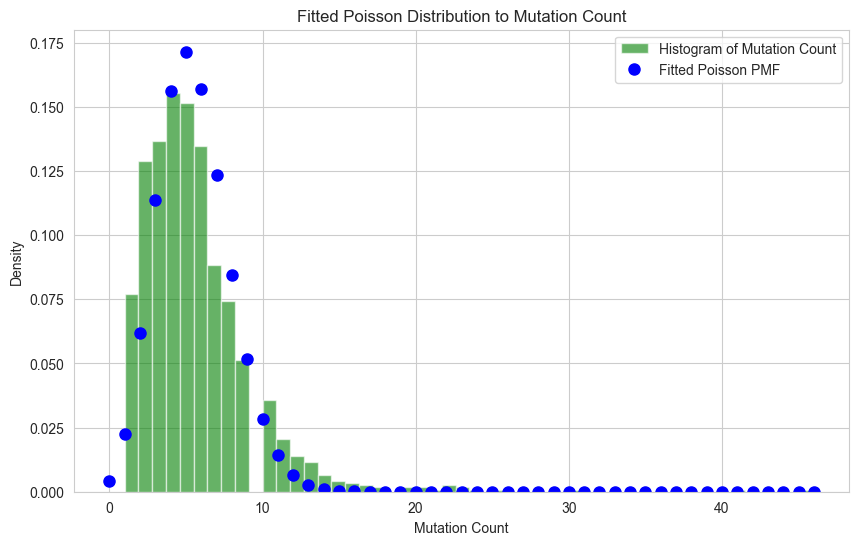

In [14]:
from scipy.stats import poisson
import numpy as np

lambda_mle = mutation_counts.mean()
print(f"MLE for λ: {lambda_mle}")

x = np.arange(0, mutation_counts.max()+1)
pmf = poisson.pmf(x, lambda_mle)
plt.figure(figsize=(10, 6))
plt.hist(mutation_counts, bins=50, density=True, alpha=0.6, color='g', label='Histogram of Mutation Count')
plt.plot(x, pmf, 'bo', ms=8, label='Fitted Poisson PMF')
plt.title('Fitted Poisson Distribution to Mutation Count')
plt.xlabel('Mutation Count')
plt.ylabel('Density')
plt.legend()
plt.show()

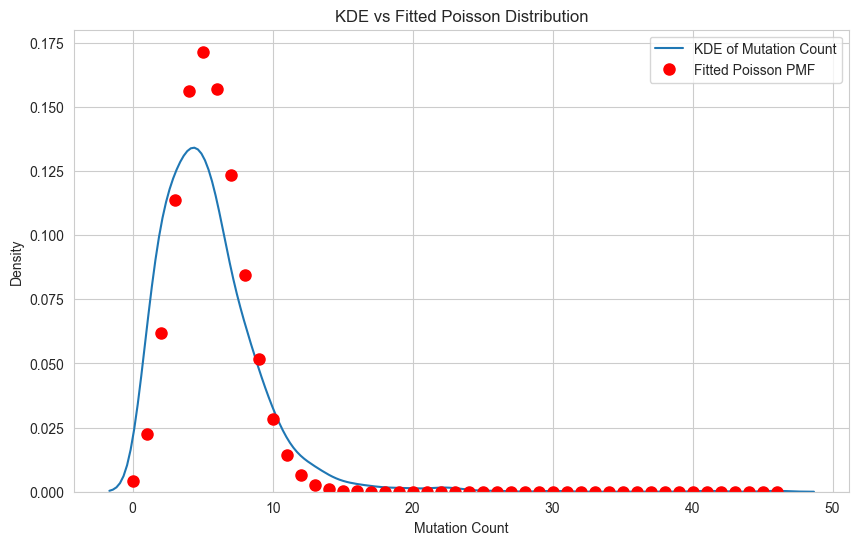

In [15]:
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.kdeplot(mutation_counts, bw_adjust=1, label='KDE of Mutation Count')
plt.plot(x, pmf, 'ro', ms=8, label='Fitted Poisson PMF')
plt.title('KDE vs Fitted Poisson Distribution')
plt.xlabel('Mutation Count')
plt.ylabel('Density')
plt.legend()
plt.show()

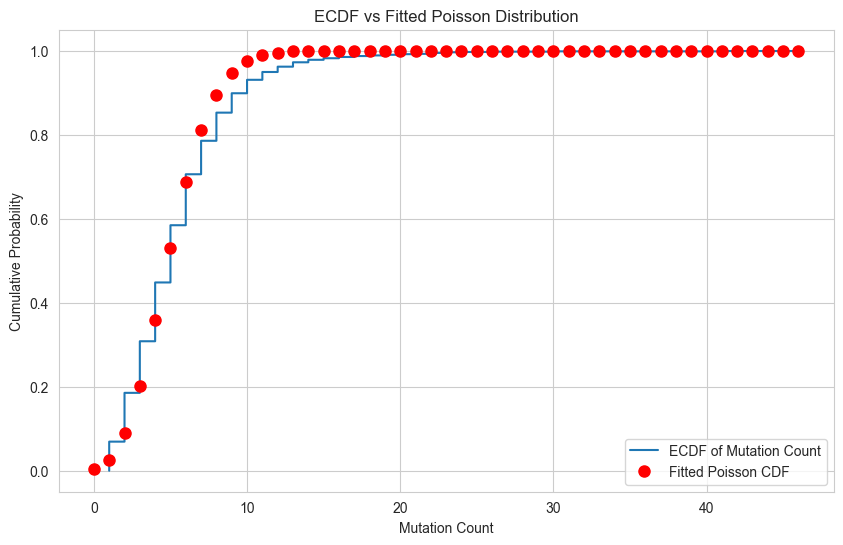

In [16]:
from statsmodels.distributions.empirical_distribution import ECDF

ecdf = ECDF(mutation_counts)

plt.figure(figsize=(10, 6))
plt.step(ecdf.x, ecdf.y, label='ECDF of Mutation Count', where='post')
plt.plot(x, poisson.cdf(x, lambda_mle), 'ro', ms=8, label='Fitted Poisson CDF')
plt.title('ECDF vs Fitted Poisson Distribution')
plt.xlabel('Mutation Count')
plt.ylabel('Cumulative Probability')
plt.legend()
plt.show()

The Poisson distribution provides a reasonable fit to the mutation count data, as evidenced by the close alignment between the histogram/KDE/ECDF and the fitted Poisson PMF/CDF. However, there may be some discrepancies at higher density, suggesting that while the Poisson model captures the general trend, it may not fully account for all aspects of the data distribution.

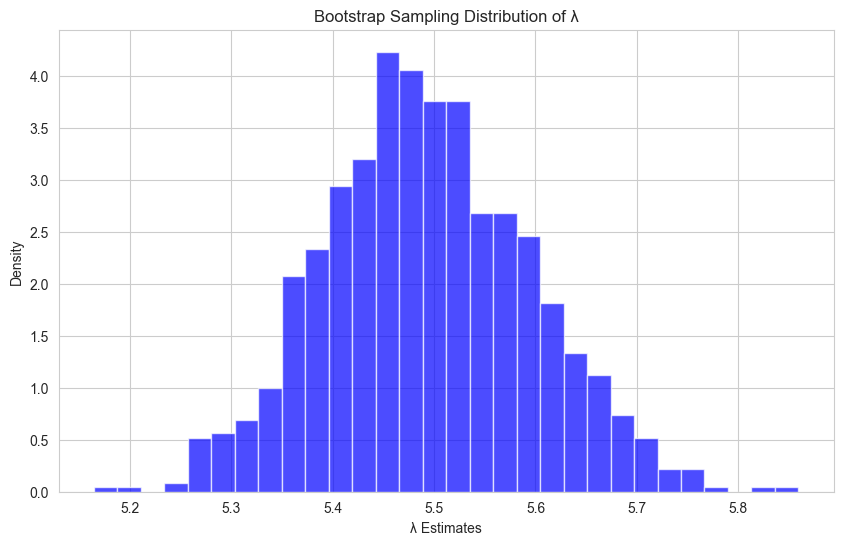

In [17]:
n_bootstraps = 1000
bootstrap_estimates = []

for _ in range(n_bootstraps):
    sample = mutation_counts.sample(frac=1, replace=True)
    lambda_bootstrap = sample.mean()
    bootstrap_estimates.append(lambda_bootstrap)

plt.figure(figsize=(10, 6))
plt.hist(bootstrap_estimates, bins=30, density=True, alpha=0.7, color='b')
plt.title('Bootstrap Sampling Distribution')
plt.xlabel('λ Estimates')
plt.ylabel('Density')
plt.show()